In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

# Helper: Random datetime generator
def random_date(start, end):
    delta = end - start
    random_days = random.randrange(delta.days)
    random_seconds = random.randrange(24 * 3600)
    return (start + timedelta(days=random_days, seconds=random_seconds)).strftime("%d/%m/%Y %H:%M")

# Chemical properties dictionary
chemicals = {
    'Ammonia': {'type': 'industrial chemical', 'LD50': 350, 'LC50': 200, 'IC50': 1.2, 'viscosity': 0.3, 'vapor_pressure': 8500, 'lethal_dosage': 3, 'threat_prob': {'low': 0.8, 'medium': 0.15, 'high': 0.05}},
    'Glyphosate': {'type': 'herbicide', 'LD50': 5600, 'LC50': 500, 'IC50': 2.5, 'viscosity': 1.7, 'vapor_pressure': 0.01, 'lethal_dosage': 10, 'threat_prob': {'low': 0.9, 'medium': 0.1, 'high': 0.0}},
    'Sarin': {'type': 'G-series nerve agent', 'LD50': 100, 'LC50': 75, 'IC50': 0.05, 'viscosity': 0.6, 'vapor_pressure': 2900, 'lethal_dosage': 0.5, 'threat_prob': {'low': 0.0, 'medium': 0.1, 'high': 0.9}},
    'VX': {'type': 'V-series nerve agent', 'LD50': 10, 'LC50': 30, 'IC50': 0.01, 'viscosity': 14, 'vapor_pressure': 10, 'lethal_dosage': 0.02, 'threat_prob': {'low': 0.0, 'medium': 0.05, 'high': 0.95}},
    'Malathion': {'type': 'pesticide', 'LD50': 1375, 'LC50': 210, 'IC50': 0.6, 'viscosity': 5, 'vapor_pressure': 1.78, 'lethal_dosage': 20, 'threat_prob': {'low': 0.2, 'medium': 0.75, 'high': 0.05}},
    'Urea': {'type': 'urea-based compound', 'LD50': 8471, 'LC50': 350, 'IC50': 100, 'viscosity': 1.5, 'vapor_pressure': 0.01, 'lethal_dosage': 100, 'threat_prob': {'low': 0.95, 'medium': 0.05, 'high': 0.0}},
    'LSD': {'type': 'CNS', 'LD50': 500, 'LC50': 200, 'IC50': 0.001, 'viscosity': 1.2, 'vapor_pressure': 0.01, 'lethal_dosage': 0.002, 'threat_prob': {'low': 0.0, 'medium': 0.1, 'high': 0.9}},
    'Soman': {'type': 'G-series nerve agent', 'LD50': 50, 'LC50': 50, 'IC50': 0.04, 'viscosity': 0.8, 'vapor_pressure': 2400, 'lethal_dosage': 0.4, 'threat_prob': {'low': 0.0, 'medium': 0.05, 'high': 0.95}}
}

incident_types = ['accident', 'intentional release', 'sabotage', 'test']
env_impacts = ['none', 'minimal', 'moderate', 'severe']
precipitation_options = ['yes', 'no']
threat_levels = ['low', 'medium', 'high']
start_date = datetime(2023, 1, 1)
end_date = datetime(2025, 12, 31)

# Controlled sampling
samples_per_class = 500  # Adjust for balance
final_data = []

def generate_sample(threat_level_target):
    while True:
        chemical = random.choice(list(chemicals.keys()))
        props = chemicals[chemical]

        # Inject noise realistically
        LD50 = max(props['LD50'] * np.random.normal(1, 0.1), 1)
        LC50 = max(props['LC50'] * np.random.normal(1, 0.1), 1)
        IC50 = max(props['IC50'] * np.random.normal(1, 0.1), 0.001)
        viscosity = max(props['viscosity'] * np.random.normal(1, 0.1), 0.1)
        vapor_pressure = max(props['vapor_pressure'] * np.random.normal(1, 0.1), 0.01)
        lethal_dosage = max(props['lethal_dosage'] * np.random.normal(1, 0.1), 0.001)

        latitude = np.random.uniform(28.4, 28.9)  # e.g. near Delhi
        longitude = np.random.uniform(76.8, 77.5)
        quantity = np.random.lognormal(mean=4.5, sigma=0.7)
        temperature = np.random.normal(25, 7)
        humidity = np.random.uniform(20, 90)
        wind_speed = np.random.uniform(0, 20)
        wind_dir = np.random.uniform(0, 360)
        nearby_population = np.random.lognormal(mean=6, sigma=2)
        nearby_population = min(max(nearby_population, 0), 10000)
        proximity_sensitive_sites = np.random.uniform(0, 20)
        emergency_distance = np.random.uniform(0, 20)
        precipitation = random.choice(precipitation_options)
        incident_type = random.choice(incident_types)
        env_impact = random.choice(env_impacts)
        date_time = random_date(start_date, end_date)

        # Threat level decision logic
        predicted_level = 'low'
        if (lethal_dosage < 0.1 or LD50 < 50 or LC50 < 50) and quantity > 300 and wind_speed > 7 and nearby_population > 2000:
            predicted_level = 'high'
        elif (LD50 < 500 and LD50 > 50 and quantity > 100 and quantity <= 300 and nearby_population > 500 and wind_speed > 4):
            predicted_level = 'medium'
        elif env_impact == 'severe' or incident_type in ['intentional release', 'sabotage']:
            predicted_level = 'high'
        else:
            predicted_level = 'low'

        # Enforce target class
        if predicted_level == threat_level_target:
            return [
                latitude, longitude, date_time, chemical, props['type'], quantity,
                temperature, humidity, precipitation, wind_speed, wind_dir, nearby_population,
                proximity_sensitive_sites, emergency_distance, incident_type, env_impact,
                LD50, LC50, IC50, viscosity, vapor_pressure, lethal_dosage, predicted_level
            ]

# Generate balanced samples
for level in threat_levels:
    for _ in range(samples_per_class):
        sample = generate_sample(level)
        final_data.append(sample)

# Create DataFrame
columns = [
    'latitude', 'longitude', 'date_time', 'chemical_name', 'chemical_type', 'quantity_released',
    'temperature', 'humidity', 'precipitation', 'wind_speed', 'wind_direction', 'nearby_population',
    'proximity_sensitive_sites', 'emergency_services_distance', 'incident_type', 'environmental_impact',
    'LD50', 'LC50', 'IC50', 'viscosity', 'vapor_pressure', 'lethal_dosage', 'threat_level'
]
df = pd.DataFrame(final_data, columns=columns)

# Final check and save
print("✅ Dataset shape:", df.shape)
print("📊 Class Distribution:\n", df['threat_level'].value_counts())
df.to_csv('balanced_chemical_incidents_dataset.csv', index=False)
print("📁 Saved: balanced_chemical_incidents_dataset.csv")


✅ Dataset shape: (1500, 23)
📊 Class Distribution:
 threat_level
low       500
medium    500
high      500
Name: count, dtype: int64
📁 Saved: balanced_chemical_incidents_dataset.csv


📊 Classification Report:

              precision    recall  f1-score   support

        high       1.00      0.99      0.99       100
         low       1.00      0.94      0.97       100
      medium       0.93      1.00      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



/tmp/ipython-input-3798522416.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp[:20], y=feat_imp.index[:20], palette="viridis")


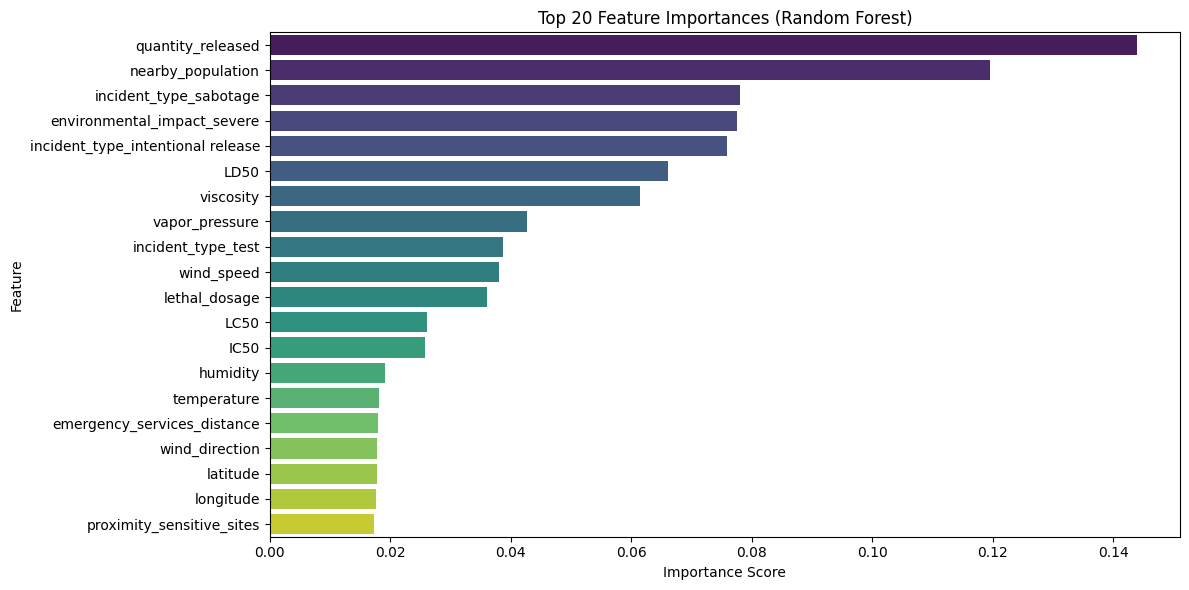

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('balanced_chemical_incidents_dataset.csv')

# 2. Drop unused columns (date_time, if not relevant)
df.drop(columns=['date_time'], inplace=True)

# 3. Encode target labels
le_target = LabelEncoder()
df['threat_level_encoded'] = le_target.fit_transform(df['threat_level'])

# 4. Encode categorical input features
categorical_cols = ['chemical_name', 'chemical_type', 'precipitation', 'incident_type', 'environmental_impact']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Separate features and labels
X = df_encoded.drop(columns=['threat_level', 'threat_level_encoded'])
y = df_encoded['threat_level_encoded']

# 6. Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 7. Optional: Scale numerical features (RandomForest doesn't need it but useful for other models)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# 8. Train model
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# 9. Predictions and evaluation
y_pred = clf.predict(X_test)
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 10. Feature Importance Plot
importances = clf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 20 important features
plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp[:20], y=feat_imp.index[:20], palette="viridis")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# Load and prepare data
df = pd.read_csv('balanced_chemical_incidents_dataset.csv')
df.drop(columns=['date_time'], inplace=True)

# Encode target labels
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df['threat_level_encoded'] = le_target.fit_transform(df['threat_level'])

# One-hot encode categorical features
categorical_cols = ['chemical_name', 'chemical_type', 'precipitation', 'incident_type', 'environmental_impact']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Train-test split
X = df_encoded.drop(columns=['threat_level', 'threat_level_encoded'])
y = df_encoded['threat_level_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


📊 Classification Report:

              precision    recall  f1-score   support

        high       1.00      0.99      0.99       100
         low       1.00      0.94      0.97       100
      medium       0.93      1.00      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


📊 Cross-Validation Accuracy Scores: [0.9867 0.9867 0.9967 0.9833 0.99  ]
📈 Mean CV Accuracy: 0.9887 ± 0.0045

🏋️ Training Accuracy: 1.0
🧪 Testing Accuracy: 0.9767
✅ No major overfitting detected.

📋 Classification Report:

              precision    recall  f1-score   support

        high       1.00      0.99      0.99       100
         low       1.00      0.94      0.97       100
      medium       0.93      1.00      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



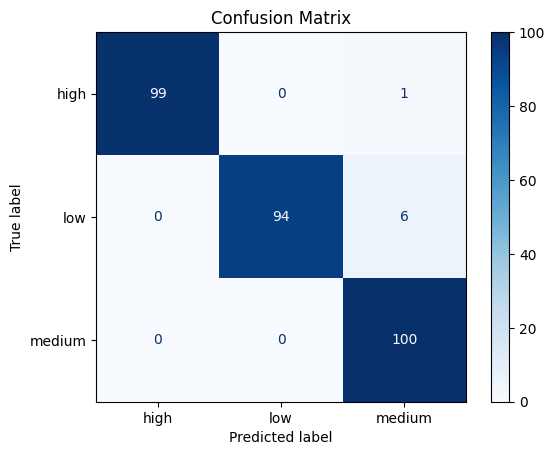

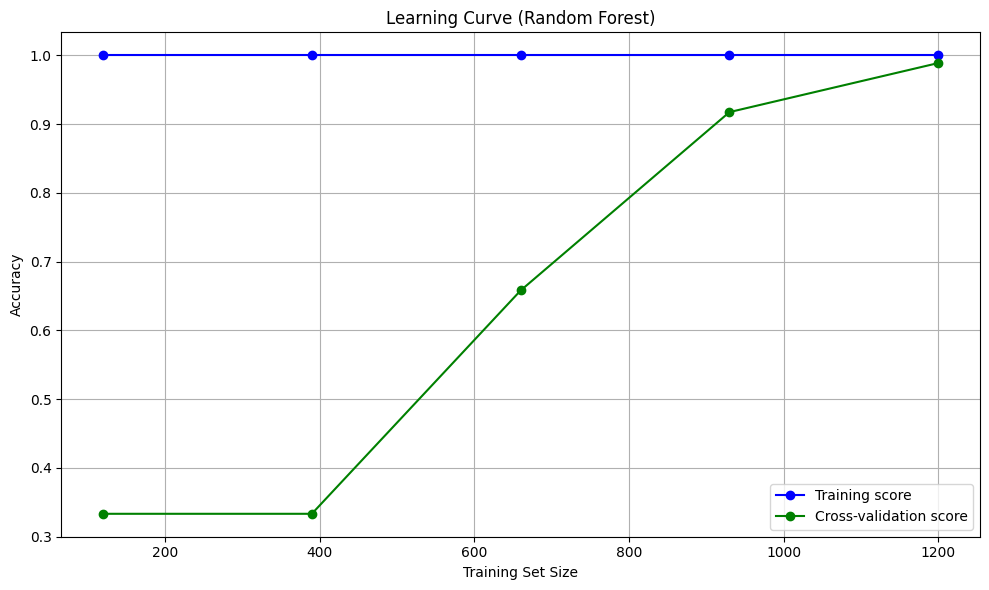

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load and preprocess data
df = pd.read_csv('balanced_chemical_incidents_dataset.csv')
df.drop(columns=['date_time'], inplace=True)

# Encode target
le_target = LabelEncoder()
df['threat_level_encoded'] = le_target.fit_transform(df['threat_level'])

# One-hot encode categoricals
categorical_cols = ['chemical_name', 'chemical_type', 'precipitation', 'incident_type', 'environmental_impact']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features and target
X = df_encoded.drop(columns=['threat_level', 'threat_level_encoded'])
y = df_encoded['threat_level_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define model
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# 1. Cross-validation (Stratified K-Fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print("📊 Cross-Validation Accuracy Scores:", np.round(cv_scores, 4))
print("📈 Mean CV Accuracy:", round(np.mean(cv_scores), 4), "±", round(np.std(cv_scores), 4))

# 2. Train model on training set
clf.fit(X_train, y_train)
train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)

print("\n🏋️ Training Accuracy:", round(train_score, 4))
print("🧪 Testing Accuracy:", round(test_score, 4))

# 3. Check for overfitting
if train_score - test_score > 0.1:
    print("⚠️ Potential Overfitting Detected.")
else:
    print("✅ No major overfitting detected.")

# 4. Classification Report
y_pred = clf.predict(X_test)
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 6. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    clf, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy', random_state=42)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training score", color="blue")
plt.plot(train_sizes, test_scores_mean, 'o-', label="Cross-validation score", color="green")
plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:20] WARNING: /w

📊 XGBoost CV Scores: [0.9933 0.9967 0.9933 0.9867 0.99  ]
📈 Mean CV Accuracy: 0.992 ± 0.0034

🏋️ Train Accuracy: 1.0
🧪 Test Accuracy: 0.9933

📋 Classification Report:

              precision    recall  f1-score   support

        high       0.99      1.00      1.00       100
         low       1.00      0.99      0.99       100
      medium       0.99      0.99      0.99       100

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



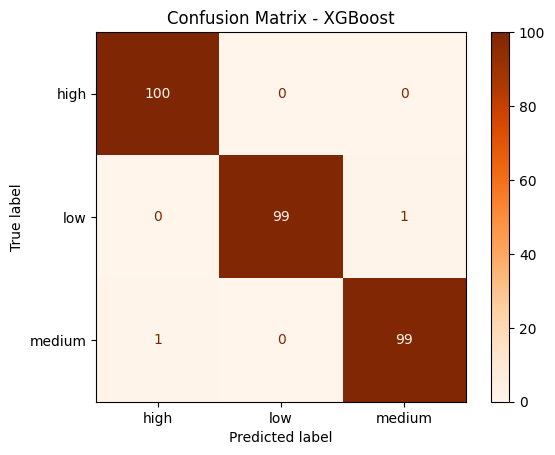

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('balanced_chemical_incidents_dataset.csv')
df.drop(columns=['date_time'], inplace=True)

# 2. Encode target
le_target = LabelEncoder()
df['threat_level_encoded'] = le_target.fit_transform(df['threat_level'])

# 3. One-hot encode categorical features
categorical_cols = ['chemical_name', 'chemical_type', 'precipitation', 'incident_type', 'environmental_impact']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Prepare features and target
X = df_encoded.drop(columns=['threat_level', 'threat_level_encoded'])
y = df_encoded['threat_level_encoded']

# 5. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 6. Train XGBoost model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# 7. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='accuracy')

print("📊 XGBoost CV Scores:", np.round(cv_scores, 4))
print("📈 Mean CV Accuracy:", round(np.mean(cv_scores), 4), "±", round(np.std(cv_scores), 4))

# 8. Test performance
train_acc = xgb.score(X_train, y_train)
test_acc = xgb.score(X_test, y_test)
print("\n🏋️ Train Accuracy:", round(train_acc, 4))
print("🧪 Test Accuracy:", round(test_acc, 4))

# 9. Classification report
y_pred = xgb.predict(X_test)
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 10. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:27] WARNING: /w

📊 VotingClassifier CV Accuracy: [0.99   0.9967 0.9967 0.99   0.9933]
📈 Mean: 0.9933 ± 0.003


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:56:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🏋️ Train Accuracy: 1.0
🧪 Test Accuracy: 0.9933333333333333

📋 VotingClassifier Report:

              precision    recall  f1-score   support

        high       1.00      1.00      1.00       100
         low       1.00      0.98      0.99       100
      medium       0.98      1.00      0.99       100

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



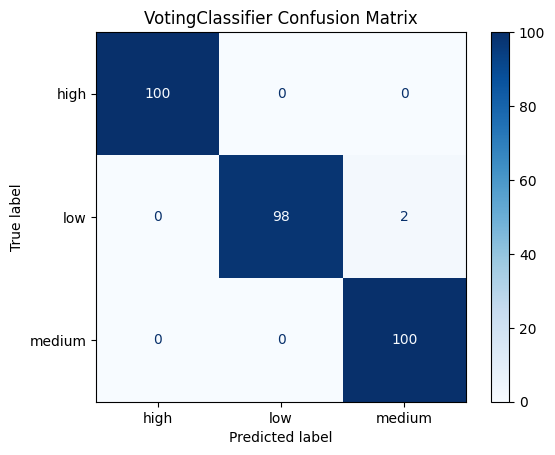

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and encode dataset
df = pd.read_csv('balanced_chemical_incidents_dataset.csv')
df.drop(columns=['date_time'], inplace=True)

label_encoders = {}

for col in ['chemical_name', 'chemical_type', 'precipitation', 'incident_type', 'environmental_impact']:
    le_col = LabelEncoder()
    df[col] = le_col.fit_transform(df[col])
    label_encoders[col] = le_col

# Encode target
le_target = LabelEncoder()
df['threat_level_encoded'] = le_target.fit_transform(df['threat_level'])
label_encoders['threat_level'] = le_target


X = df.drop(columns=['threat_level', 'threat_level_encoded'])
y = df['threat_level_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Define base models
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', subsample=0.8, colsample_bytree=0.8, random_state=42)

# Voting classifier
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_clf, X, y, cv=cv, scoring='accuracy')
print("📊 VotingClassifier CV Accuracy:", np.round(cv_scores, 4))
print("📈 Mean:", round(np.mean(cv_scores), 4), "±", round(np.std(cv_scores), 4))

# Fit on training
voting_clf.fit(X_train, y_train)
print("\n🏋️ Train Accuracy:", voting_clf.score(X_train, y_train))
print("🧪 Test Accuracy:", voting_clf.score(X_test, y_test))

# Report
y_pred = voting_clf.predict(X_test)
print("\n📋 VotingClassifier Report:\n")
# print(classification_report(y_test, y_pred, target_names=le.classes_))
print(classification_report(y_test, y_pred, target_names=label_encoders['threat_level'].classes_))


# Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(voting_clf, X_test, y_test,display_labels=label_encoders['threat_level'].classes_, cmap='Blues')
plt.title("VotingClassifier Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd

# Model performance metrics
data = {
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression', 'VotingClassifier (Ensemble)'],
    'Accuracy': [0.9833, 0.9933, 0.964, 0.99],
    'Precision (Macro)': [0.98, 0.99, 0.96, 0.99],
    'Recall (Macro)': [0.98, 0.99, 0.96, 0.99],
    'F1-Score (Macro)': [0.98, 0.99, 0.96, 0.99]
}

# Create DataFrame
df = pd.DataFrame(data)

# Export to CSV (optional)
df.to_csv("model_performance_comparison.csv", index=False)

# Print as Markdown for academic reports
print(df.to_markdown(index=False))


| Model                       |   Accuracy |   Precision (Macro) |   Recall (Macro) |   F1-Score (Macro) |
|:----------------------------|-----------:|--------------------:|-----------------:|-------------------:|
| Random Forest               |     0.9833 |                0.98 |             0.98 |               0.98 |
| XGBoost                     |     0.9933 |                0.99 |             0.99 |               0.99 |
| Logistic Regression         |     0.964  |                0.96 |             0.96 |               0.96 |
| VotingClassifier (Ensemble) |     0.99   |                0.99 |             0.99 |               0.99 |


In [ ]:
import joblib
import os

# Assume you have these already from your code
# voting_clf (VotingClassifier), le_target (LabelEncoder), scaler if used

os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(voting_clf, "models/voting_classifier.pkl")

# Save LabelEncoder
# joblib.dump(le_target, "models/label_encoder.pkl")
# joblib.dump({'threat_level': le}, "models/label_encoder.pkl")
joblib.dump(label_encoders, "models/label_encoders.pkl")



# Optional: if you used scaling (e.g., StandardScaler), save that too
# joblib.dump(scaler, "models/scaler.pkl")

print("✅ All models and encoders saved in 'models/' folder.")


✅ All models and encoders saved in 'models/' folder.


In [ ]:
feat_imp.to_csv("models/feature_importance_rf.csv")


In [ ]:
import joblib
import pandas as pd

# Load model and encoders
model = joblib.load("/content/models/voting_classifier.pkl")
encoders = joblib.load("/content/models/label_encoders.pkl")
# scaler = joblib.load("models/scaler.pkl")

def predict_threat(input_data: dict):
    df = pd.DataFrame([input_data])

    # Apply encoding and scaling
    for col, le in encoders.items():
        df[col] = le.transform(df[col])

    df_scaled = scaler.transform(df)
    pred = model.predict(df_scaled)
    proba = model.predict_proba(df_scaled)
    return pred[0], proba[0]


In [ ]:
def predict_threat(input_data: dict, model, encoder):
    df = pd.DataFrame([input_data])

    # Convert categorical features
    df = pd.get_dummies(df)
    for col in X.columns:
        if col not in df.columns:
            df[col] = 0  # Add missing columns

    df = df[X.columns]  # Ensure same column order

    prediction = model.predict(df)[0]
    probability = model.predict_proba(df)[0]
    threat_label = encoder.inverse_transform([prediction])[0]
    return threat_label, probability


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import joblib

# After final X is created and used to train the model
X_columns = X.columns.tolist()
joblib.dump(X_columns, "models/feature_columns.pkl")
print("✅ Saved feature columns to models/feature_columns.pkl")


✅ Saved feature columns to models/feature_columns.pkl


In [ ]:
from osmnx import features

In [ ]:
!pip install streamlit

In [ ]:
!pip install streamlit-folium


In [ ]:
!pip install streamlit streamlit-folium pyngrok geopandas folium geopy joblib


In [ ]:
from pyngrok import ngrok

# Replace with your actual authtoken from ngrok
ngrok.set_auth_token("2x63EWXriD5mC4EgRpeRohdOP6z_5Lab6BfYEYNB6aC6XiPgr")


In [ ]:
!pip install streamlit pyngrok streamlit-folium geopy --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 23.5 MB/s eta 0:00:00


In [ ]:
code = '''
import streamlit as st
import pandas as pd
import joblib
import folium
from streamlit_folium import st_folium
from geopy.geocoders import Nominatim

# Load model and encoders
model = joblib.load("models/voting_classifier.pkl")
label_encoders = joblib.load("models/label_encoder.pkl")  # FIXED PATH

st.set_page_config(page_title="Chemical Threat Prediction", layout="centered")
st.title("☣️ Chemical Threat Level Predictor & Evacuation Map")
st.markdown("Provide details about the chemical incident:")

# User inputs
location = st.text_input("📍 Incident Location", "Connaught Place, Delhi")
chemical_name = st.selectbox("Chemical Name", ['Chlorine', 'Ammonia', 'Sulfur Dioxide'])
chemical_type = st.selectbox("Chemical Type", ['Toxic', 'Flammable', 'Reactive'])
incident_type = st.selectbox("Incident Type", ['Leak', 'Explosion', 'Spill'])
precipitation = st.selectbox("Precipitation", ['None', 'Light Rain', 'Heavy Rain'])
environmental_impact = st.selectbox("Environmental Impact", ['Low', 'Medium', 'High'])
temperature = st.slider("🌡️ Temperature (°C)", 0, 50, 25)
wind_speed = st.slider("🌬️ Wind Speed (m/s)", 0, 30, 5)
humidity = st.slider("💧 Humidity (%)", 0, 100, 40)
population_density = st.slider("👥 Population Density (/km²)", 0, 50000, 10000)
elevation = st.slider("⛰️ Elevation (m)", 0, 400, 200)

# Geocode location
geolocator = Nominatim(user_agent="cb_project_app")
geocode = geolocator.geocode(location)
if not geocode:
    st.error("❌ Could not geocode the location. Please try another address.")
    st.stop()

lat, lon = geocode.latitude, geocode.longitude

# Prepare input dict
input_data = {
    'chemical_name': chemical_name,
    'chemical_type': chemical_type,
    'incident_type': incident_type,
    'precipitation': precipitation,
    'environmental_impact': environmental_impact,
    'temperature': temperature,
    'wind_speed': wind_speed,
    'humidity': humidity,
    'population_density': population_density,
    'elevation': elevation
}

input_df = pd.DataFrame([input_data])

# One-hot encode to match training data
cat_cols = ['chemical_name', 'chemical_type', 'incident_type', 'precipitation', 'environmental_impact']
input_df_encoded = pd.get_dummies(input_df, columns=cat_cols)

# Align with model training features
model_features = model.feature_names_in_.astype(str)
input_df_encoded.columns = input_df_encoded.columns.astype(str)
input_df_encoded = input_df_encoded.reindex(columns=model_features, fill_value=0)

# Predict
pred = model.predict(input_df_encoded)[0]
pred_label = label_encoders['threat_level'].inverse_transform([pred])[0]

st.success(f"🚨 Predicted Threat Level: **{pred_label.upper()}**")

# Dynamic radius and color
THREAT_RADIUS_MAP = {'low': 3000, 'medium': 2000, 'high': 1000}
THREAT_COLOR_MAP = {'low': 'green', 'medium': 'orange', 'high': 'red'}

radius = THREAT_RADIUS_MAP.get(pred_label.lower(), 2000)
color = THREAT_COLOR_MAP.get(pred_label.lower(), 'gray')

# Map visualization
st.markdown("### 🗺️ Threat Zone Map")
m = folium.Map(location=[lat, lon], zoom_start=13)
folium.Marker([lat, lon], tooltip="Incident Location", icon=folium.Icon(color='red')).add_to(m)

folium.Circle(
    [lat, lon],
    radius=radius,
    color=color,
    fill=True,
    fill_opacity=0.3,
    tooltip=f"{pred_label.capitalize()} Risk ({radius // 1000} km)"
).add_to(m)

# Show map
st_folium(m, width=700, height=500)
'''

# Save to app.py
with open("app.py", "w") as f:
    f.write(code)


In [ ]:
!pkill -f ngrok


In [ ]:
import os
import time
from pyngrok import ngrok

# Kill any old streamlit process
os.system("pkill streamlit")

# Run streamlit in background
os.system("nohup streamlit run app.py &")

# Wait and expose via ngrok
time.sleep(5)
public_url = ngrok.connect(8501)
print(f"🚀 Streamlit running at: {public_url}")


In [ ]:
from pyngrok import ngrok
import time
import os

# Make sure the app.py file exists in your current directory
assert os.path.exists("app.py"), "❌ app.py not found!"

# Kill any existing Streamlit instances
os.system("pkill -f streamlit")

# Run Streamlit app in the background
!nohup streamlit run app.py > streamlit.log 2>&1 &

# Wait a few seconds to ensure server starts
time.sleep(5)

# Expose port 8501 (Streamlit default) via ngrok
public_url = ngrok.connect(port=8501)
print(f"🌐 Your Streamlit app is live at: {public_url}")


In [ ]:
from pyngrok import ngrok
import time
import os

# Kill existing Streamlit if needed
os.system("pkill streamlit")

# Run Streamlit app
!streamlit run app.py &>/content/log.txt &

# Wait & expose
time.sleep(5)
public_url = ngrok.connect(8501)
print(f"🌐 Streamlit app running at: {public_url}")
